# 📊 Proyecto EDA – Análisis del comportamiento de pago de créditos

In [3]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================

import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# Mostrar números con 2 decimales
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 📁 2. Carga de datos


In [ ]:
# ==========================================
# 2. CARGA DE DATOS
# ==========================================

ruta_archivo = r"C:\Proyectos_soy_henry\M5\proyecto_integrador_M5\PIM5_V1\data\raw\Base_de_datos.xlsx"

df = pd.read_excel(ruta_archivo)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")

Filas: 10,763
Columnas: 23


## 🔍 3. Revision Inicial

In [5]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1


In [6]:
df.tail()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
10758,9,2025-01-19 16:18:28,"2,414,886.00",10,29,Independiente,3000000,300000,204819,13.13,747.00,2,2,172.00,"1,112.00","1,112.00",NaN,0,0,1,NaN,NaN,0
10759,4,2025-01-10 16:40:21,"2,916,000.00",24,27,Empleado,2500000,400000,127460,55.97,714.00,5,4,0.00,"9,771.00","9,771.00",0.00,1,0,4,"1,958,333.00",Creciente,0
10760,4,2025-06-19 14:28:47,"4,249,200.00",36,24,Empleado,2000000,500000,140042,47.61,807.00,2,2,0.00,"1,603.00","1,603.00",0.00,1,0,0,"998,859.00",Creciente,0
10761,9,2025-03-02 11:53:41,"1,283,307.60",10,26,Empleado,1500000,600000,108958,42.89,755.00,5,3,0.00,"8,488.00","8,488.00",0.00,2,0,3,NaN,NaN,0
10762,4,2024-12-08 12:46:03,"3,915,000.00",12,24,Independiente,4000000,2000000,306174,59.32,716.00,9,7,0.00,"5,046.00","5,046.00",0.00,2,1,1,NaN,NaN,0


In [7]:
df.sample(10, random_state=42)

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
7662,9,2025-03-22 09:44:12,"2,201,137.20",10,35,Empleado,1900000,1300000,186984,95.23,718.00,0,2,0.00,0.00,NaN,NaN,0,0,0,"1,376,649.00",Decreciente,1
10469,4,2025-01-23 12:29:10,"990,060.00",12,35,Empleado,4000000,1500000,77538,95.23,730.00,6,3,0.00,"97,849.00","97,849.00",0.00,4,0,1,"4,331,963.00",Creciente,1
8116,4,2025-01-02 08:03:25,"2,391,360.00",12,27,Empleado,1900000,450000,166067,95.23,804.00,6,5,0.00,"3,208.00","3,208.00",0.00,3,0,0,"1,586,622.00",Decreciente,1
839,4,2025-05-16 09:29:11,"1,929,896.40",6,57,Empleado,9000000,3000000,287616,95.23,791.00,3,9,0.00,"89,176.00","89,176.00",0.00,2,0,0,"800,000.00",Creciente,1
1516,4,2025-03-19 16:33:03,"1,608,000.00",12,59,Independiente,1300000,150000,127114,92.00,820.00,5,2,0.00,758.00,758.00,0.00,0,0,4,NaN,NaN,1
6532,9,2025-05-17 10:08:36,"821,208.00",5,38,Independiente,5000000,2000000,133380,95.23,780.00,13,4,0.00,"10,307.00","10,307.00",0.00,4,0,3,"946,640.00",Creciente,1
856,4,2025-05-25 16:49:59,"1,783,080.00",6,39,Empleado,5200000,2000000,265719,95.23,825.00,4,2,0.00,"36,715.00","36,715.00",0.00,2,0,1,NaN,NaN,1
8384,9,2025-06-12 16:08:42,"4,822,471.20",5,32,Empleado,2500000,1200000,783260,95.23,818.00,3,2,0.00,"73,679.00","73,679.00",0.00,2,0,0,"1,016,501.00",Creciente,1
6399,9,2025-07-06 15:48:57,"1,269,000.00",2,40,Independiente,5000000,2000000,500798,95.23,791.00,2,2,0.00,"1,810.00","1,810.00",0.00,1,0,1,"954,500.00",Creciente,1
8089,9,2024-12-22 12:50:20,"1,245,224.40",10,23,Empleado,1400000,700000,105614,92.00,685.00,4,1,0.00,"11,151.00","11,151.00",NaN,3,0,0,NaN,NaN,1


## 🧬 4. Comprensión del esquema de datos

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvi

In [9]:
diccionario_datos = pd.DataFrame({
    "Variable": df.columns,
    "Tipo": df.dtypes.astype(str),
    "Valores_nulos": df.isnull().sum().values,
    "Porcentaje_nulos": (df.isnull().mean() * 100).round(2).values,
    "Valores_unicos": df.nunique().values
})

diccionario_datos

,Variable,Tipo,Valores_nulos,Porcentaje_nulos,Valores_unicos
tipo_credito,tipo_credito,int64,0,0.00,6
fecha_prestamo,fecha_prestamo,datetime64[ns],0,0.00,10758
capital_prestado,capital_prestado,float64,0,0.00,7306
plazo_meses,plazo_meses,int64,0,0.00,18
edad_cliente,edad_cliente,int64,0,0.00,54
tipo_laboral,tipo_laboral,object,0,0.00,2
salario_cliente,salario_cliente,int64,0,0.00,1385
total_otros_prestamos,total_otros_prestamos,int64,0,0.00,1538
cuota_pactada,cuota_pactada,int64,0,0.00,9836
puntaje,puntaje,float64,0,0.00,248


### Resumen General del Dataset
Volumen de datos: El conjunto contiene aproximadamente 10,764 registros (calculado a partir de los recuentos y porcentajes de nulos) distribuidos en 23 variables.

Calidad global: La calidad de la información es muy alta. 17 de las 23 variables no presentan valores nulos (100% de registros completos).

### Análisis de Valores Nulos (Faltantes)
Podemos agrupar las variables según su porcentaje de nulos:

Sin nulos (0.00%): Información clave del crédito (tipo_credito, fecha_prestamo, capital_prestado, plazo_meses, cuota_pactada), perfil del cliente (edad_cliente, salario_cliente, tipo_laboral) y variables del sector financiero.

Nulos marginales (< 6%):

puntaje_datacredito: 6 nulos (0.06%).

saldo_mora y saldo_total: 156 nulos (1.45%).

saldo_principal: 405 nulos (3.76%).

saldo_mora_codeudor: 590 nulos (5.48%).

Nulos significativos (~27.2%):

promedio_ingresos_datacredito (2,930 nulos / 27.22%) y tendencia_ingresos (2,932 nulos / 27.24%).

Interpretación de negocio: Es habitual que cerca del 27% de los clientes no cuenten con información estimada de ingresos en la central de riesgo (ej. por ser informales, no bancarizados o carecer de historial suficiente).

### 📋 Resultado de Imputaciones
No se realizaran imputaciones toda vez que las variables con nulos no se tendran en cuenta en el modelo

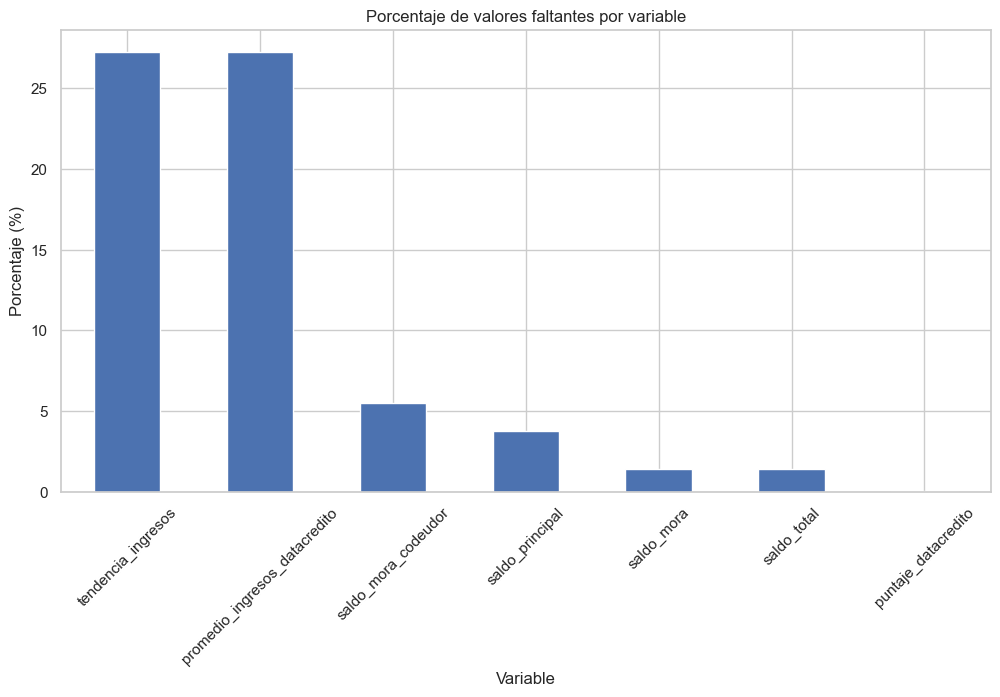

In [10]:
plt.figure(figsize=(12, 6))

nulos_pct = df.isnull().mean().sort_values(ascending=False) * 100

nulos_pct[nulos_pct > 0].plot(kind="bar")

plt.title("Porcentaje de valores faltantes por variable")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Variable")

plt.xticks(rotation=45)
plt.show()

## ⚙️ 6. Ajuste de tipos de datos

In [11]:
df.dtypes

tipo_credito                              int64
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                             object
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

In [12]:
#Ajustamos la columna fecha_prestamo a tipo datetime para poder trabajar con ella de manera más eficiente.
df["fecha_prestamo"] = pd.to_datetime(
    df["fecha_prestamo"],
    errors="coerce"
)

In [13]:
# Variables categoricas
columnas_categoricas = [
    "tipo_credito",
    "tipo_laboral",
    "tendencia_ingresos"
]

for col in columnas_categoricas:
    df[col] = df[col].astype("category")

df.dtypes

tipo_credito                           category
fecha_prestamo                   datetime64[ns]
capital_prestado                        float64
plazo_meses                               int64
edad_cliente                              int64
tipo_laboral                           category
salario_cliente                           int64
total_otros_prestamos                     int64
cuota_pactada                             int64
puntaje                                 float64
puntaje_datacredito                     float64
cant_creditosvigentes                     int64
huella_consulta                           int64
saldo_mora                              float64
saldo_total                             float64
saldo_principal                         float64
saldo_mora_codeudor                     float64
creditos_sectorFinanciero                 int64
creditos_sectorCooperativo                int64
creditos_sectorReal                       int64
promedio_ingresos_datacredito           

## 🔬 7. Análisis de la variable objetivo

In [14]:
# Variable objetivo
df["Pago_atiempo"].value_counts()

Pago_atiempo
1    10252
0      511
Name: count, dtype: int64

In [15]:
df["Pago_atiempo"].value_counts(normalize=True) * 100

Pago_atiempo
1   95.25
0    4.75
Name: proportion, dtype: float64

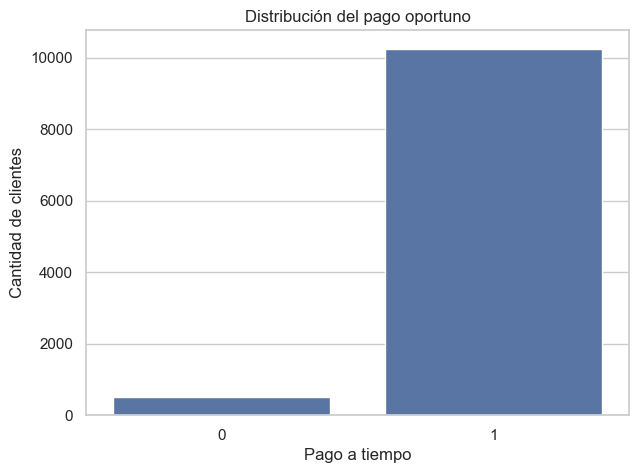

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Pago_atiempo"
)

plt.title("Distribución del pago oportuno")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de clientes")

plt.show()

### Se evidencia desbalanceo de clases
Pago_atiempo
1   95.25
0    4.75

## 8. 📌 Análisis univariable

In [17]:
#Variables numéricas
variables_numericas = df.select_dtypes(
    include=["int64", "float64"]
).columns

variables_numericas

Index(['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
       'total_otros_prestamos', 'cuota_pactada', 'puntaje',
       'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta',
       'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor',
       'creditos_sectorFinanciero', 'creditos_sectorCooperativo',
       'creditos_sectorReal', 'promedio_ingresos_datacredito', 'Pago_atiempo'],
      dtype='object')

In [18]:
# Estadisticas descriptivas
df[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
capital_prestado,"10,763.00","2,434,315.00","1,909,642.76","360,000.00","1,224,831.00","1,921,920.00","3,084,840.00","41,444,152.80"
plazo_meses,"10,763.00",10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,"10,763.00",43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,"10,763.00","17,216,431.46","355,476,717.60",0.00,"2,000,000.00","3,000,000.00","4,875,808.00","22,000,000,000.00"
total_otros_prestamos,"10,763.00","6,238,869.65","118,418,316.94",0.00,"500,000.00","1,000,000.00","2,000,000.00","6,787,675,263.00"
cuota_pactada,"10,763.00","243,617.41","210,493.69","23,944.00","121,041.50","182,863.00","287,833.50","3,816,752.00"
puntaje,"10,763.00",91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,"10,757.00",780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,"10,763.00",5.73,3.98,0.00,3.00,5.00,8.00,62.00
huella_consulta,"10,763.00",4.23,3.06,0.00,2.00,4.00,6.00,29.00


In [19]:
estadisticas = pd.DataFrame(index=variables_numericas)

estadisticas["media"] = df[variables_numericas].mean()
estadisticas["mediana"] = df[variables_numericas].median()
estadisticas["moda"] = df[variables_numericas].mode().iloc[0]
estadisticas["min"] = df[variables_numericas].min()
estadisticas["max"] = df[variables_numericas].max()
estadisticas["rango"] = (
    df[variables_numericas].max()
    - df[variables_numericas].min()
)
estadisticas["desv_std"] = df[variables_numericas].std()
estadisticas["varianza"] = df[variables_numericas].var()
estadisticas["Q1"] = df[variables_numericas].quantile(0.25)
estadisticas["Q3"] = df[variables_numericas].quantile(0.75)

estadisticas["IQR"] = (
    estadisticas["Q3"]
    - estadisticas["Q1"]
)

estadisticas["skewness"] = df[variables_numericas].skew()
estadisticas["kurtosis"] = df[variables_numericas].kurtosis()

estadisticas

,media,mediana,moda,min,max,rango,desv_std,varianza,Q1,Q3,IQR,skewness,kurtosis
capital_prestado,"2,434,315.00","1,921,920.00","1,200,000.00","360,000.00","41,444,152.80","41,084,152.80","1,909,642.76","3,646,735,466,988.66","1,224,831.00","3,084,840.00","1,860,009.00",3.72,35.32
plazo_meses,10.58,10.00,6.00,2.00,90.00,88.00,6.63,43.98,6.00,12.00,6.00,2.46,7.78
edad_cliente,43.95,42.00,40.00,19.00,123.00,104.00,15.06,226.83,33.00,53.00,20.00,1.93,7.87
salario_cliente,"17,216,431.46","3,000,000.00","3,000,000.00",0.00,"22,000,000,000.00","22,000,000,000.00","355,476,717.60","126,363,696,758,146,032.00","2,000,000.00","4,875,808.00","2,875,808.00",43.78,"2,211.23"
total_otros_prestamos,"6,238,869.65","1,000,000.00","2,000,000.00",0.00,"6,787,675,263.00","6,787,675,263.00","118,418,316.94","14,022,897,787,155,474.00","500,000.00","2,000,000.00","1,500,000.00",38.46,"1,719.28"
cuota_pactada,"243,617.41","182,863.00","205,990.00","23,944.00","3,816,752.00","3,792,808.00","210,493.69","44,307,595,469.58","121,041.50","287,833.50","166,792.00",3.79,26.65
puntaje,91.17,95.23,95.23,-38.01,95.23,133.24,16.47,271.11,95.23,95.23,0.00,-4.87,24.08
puntaje_datacredito,780.79,791.00,0.00,-7.00,999.00,"1,006.00",104.88,"10,999.40",757.00,825.00,68.00,-5.64,39.44
cant_creditosvigentes,5.73,5.00,4.00,0.00,62.00,62.00,3.98,15.82,3.00,8.00,5.00,1.80,8.62
huella_consulta,4.23,4.00,2.00,0.00,29.00,29.00,3.06,9.39,2.00,6.00,4.00,1.49,4.00


## 📊  9. Histogramas

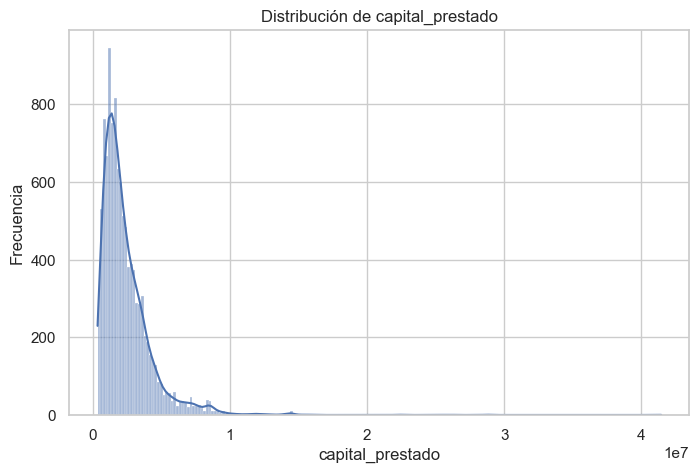

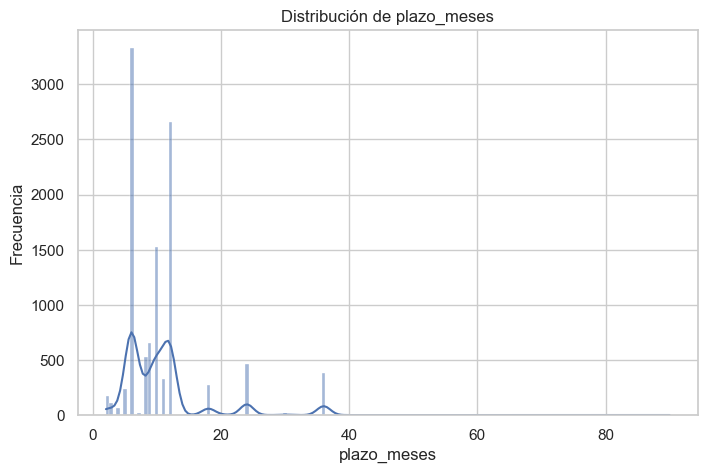

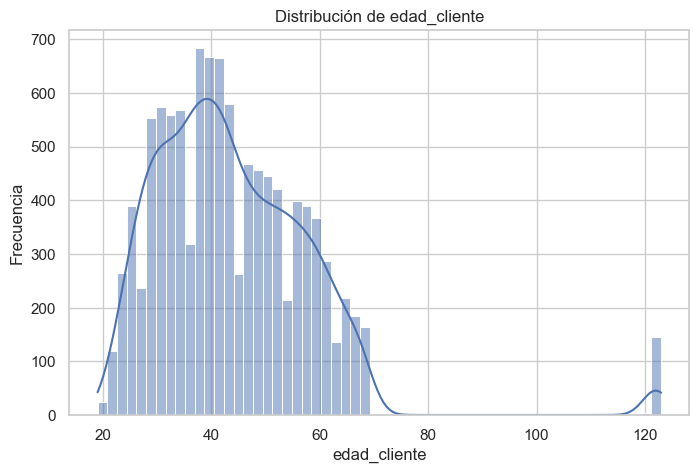

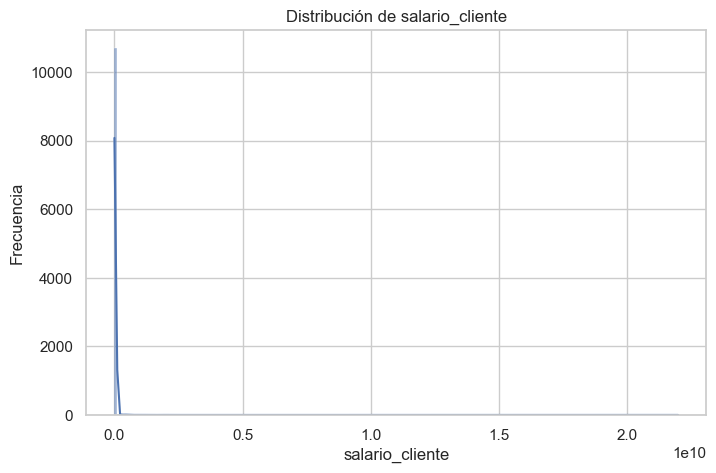

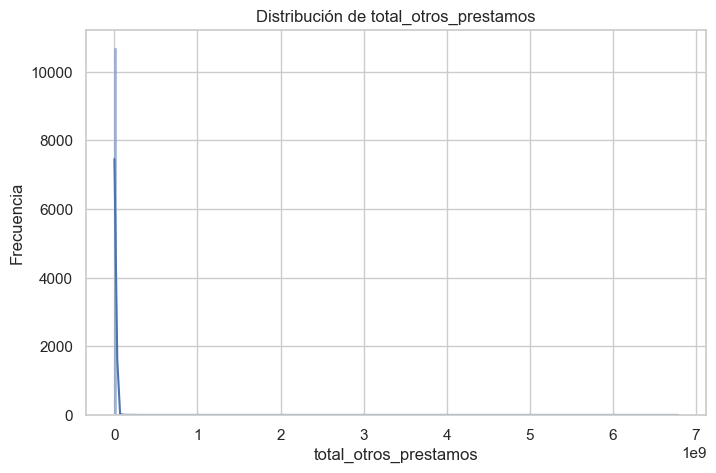

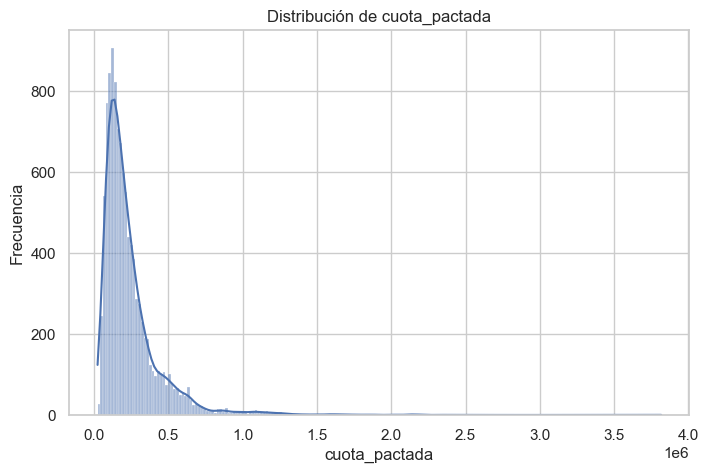

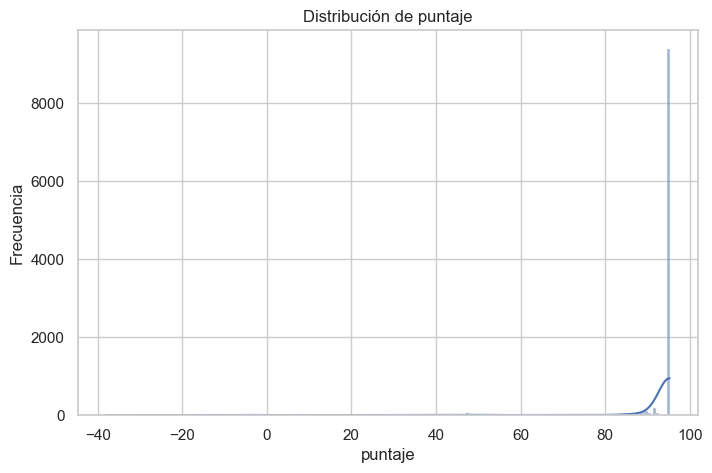

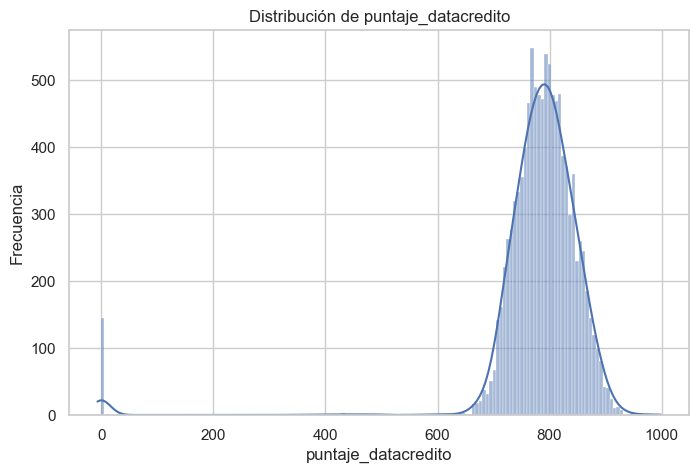

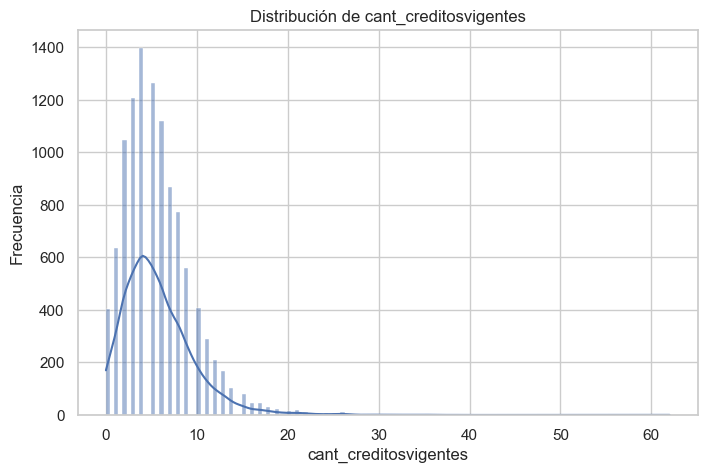

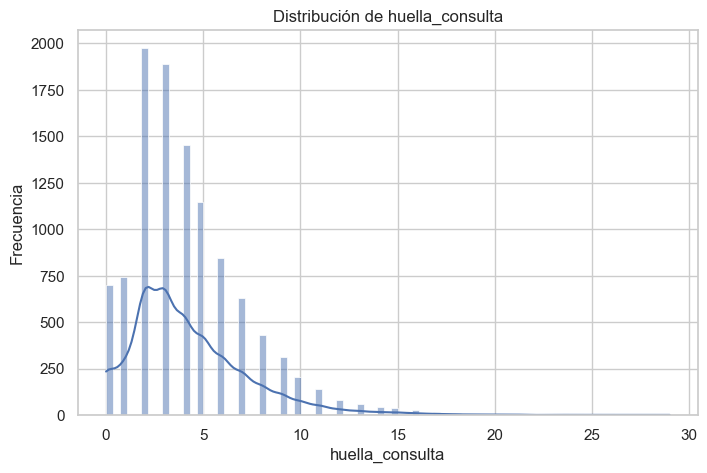

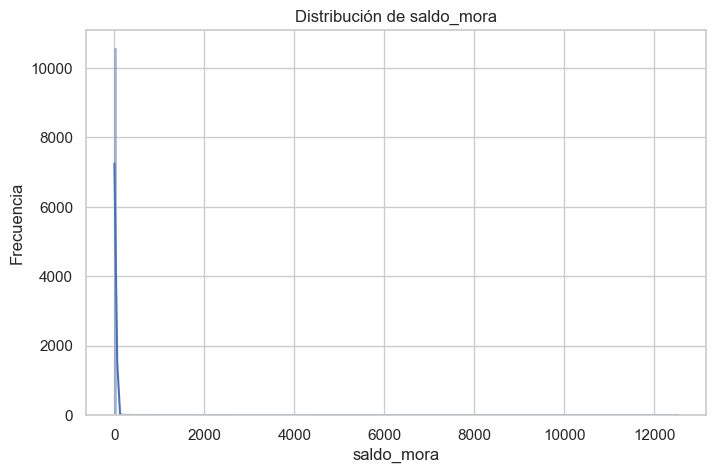

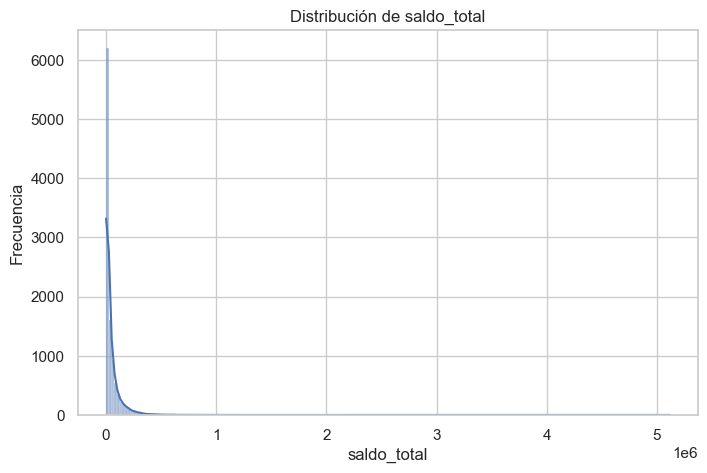

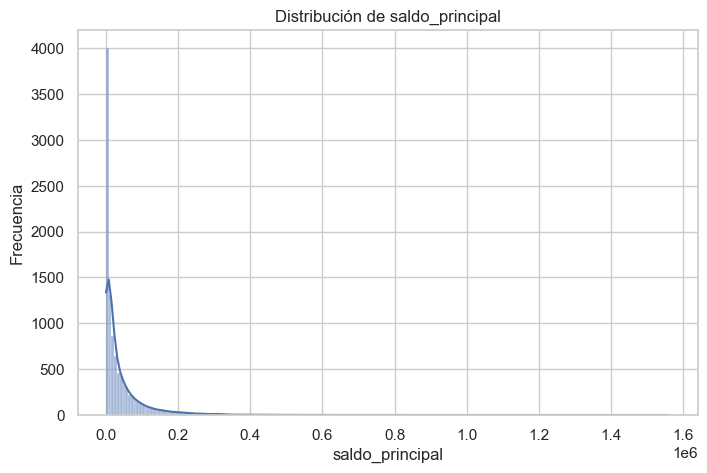

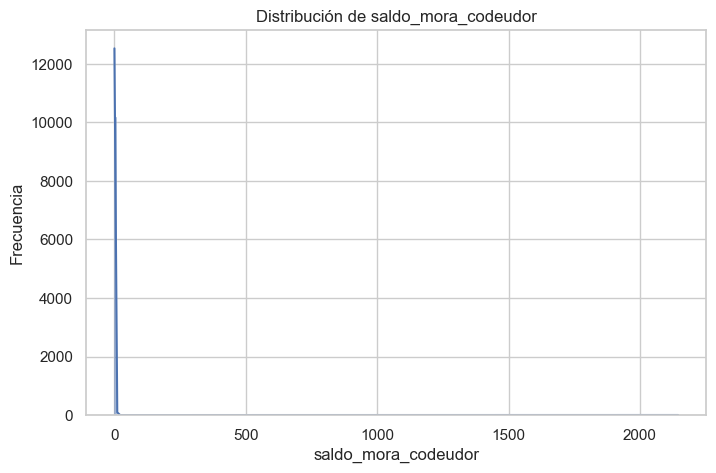

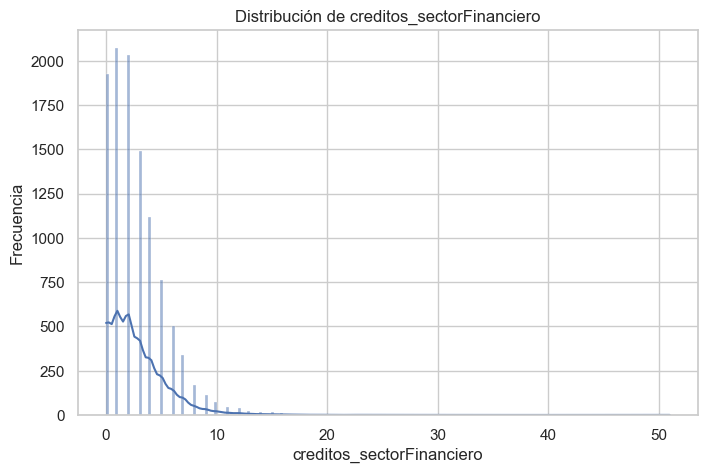

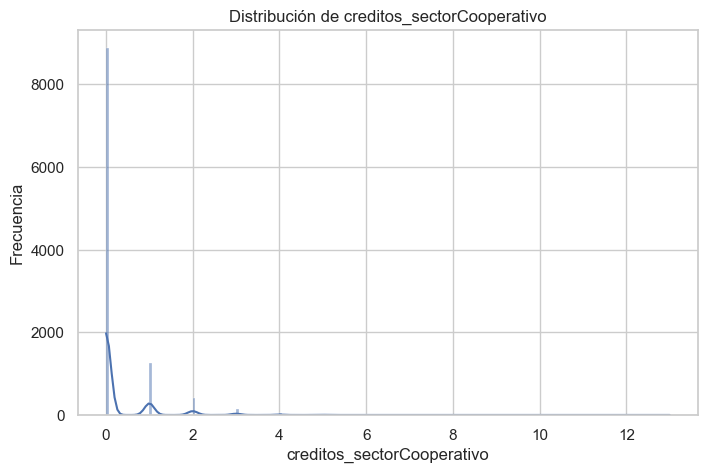

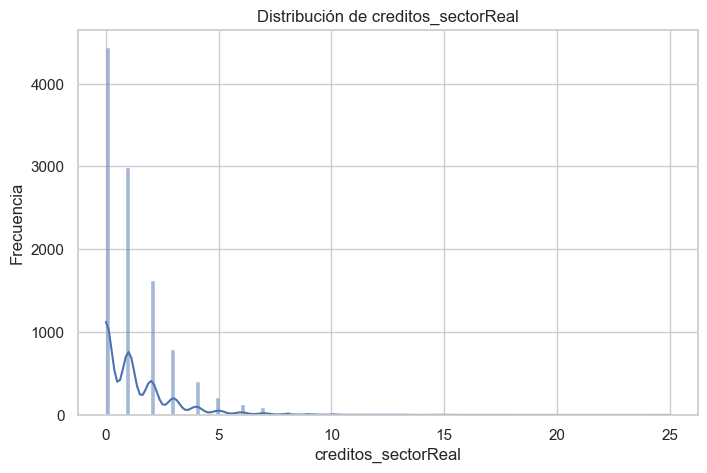

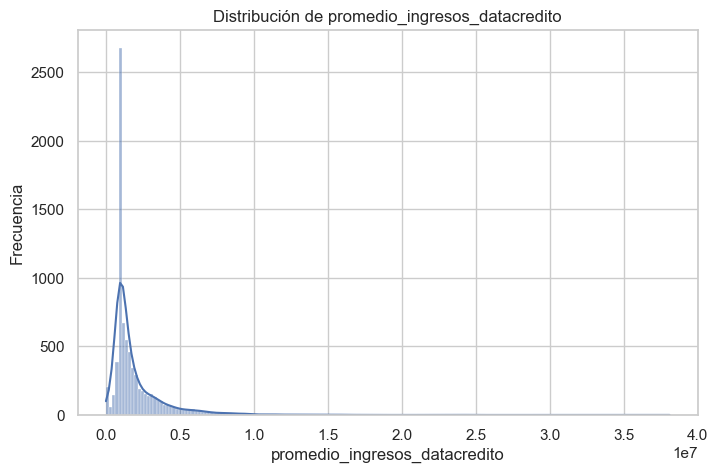

In [20]:
variables_numericas_sin_target = [
    col for col in variables_numericas
    if col != "Pago_atiempo"
]

for col in variables_numericas_sin_target:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

    plt.show()

## 📊 10. Boxplots

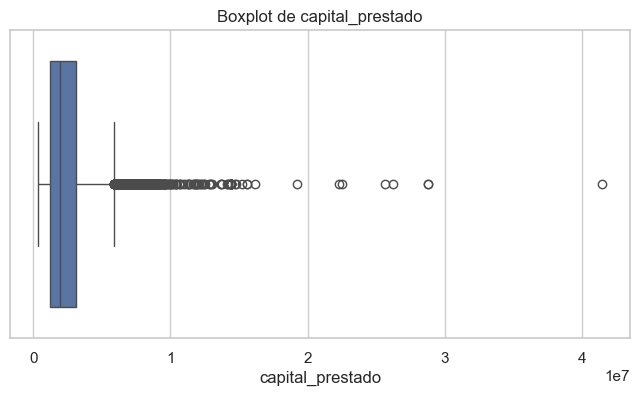

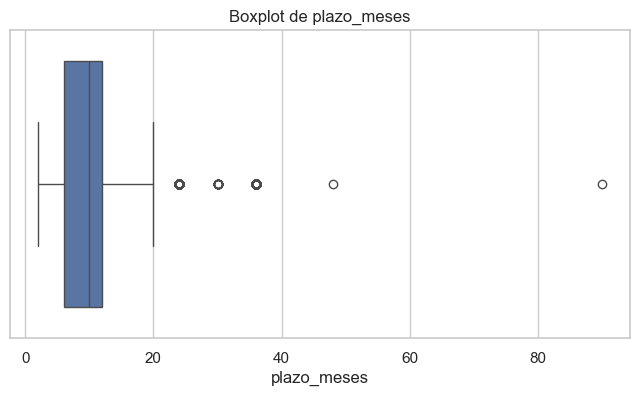

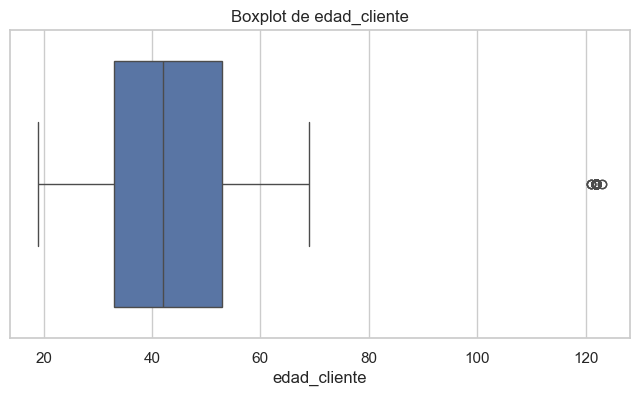

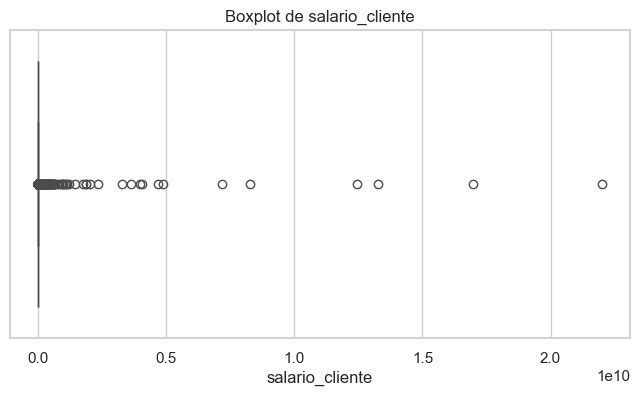

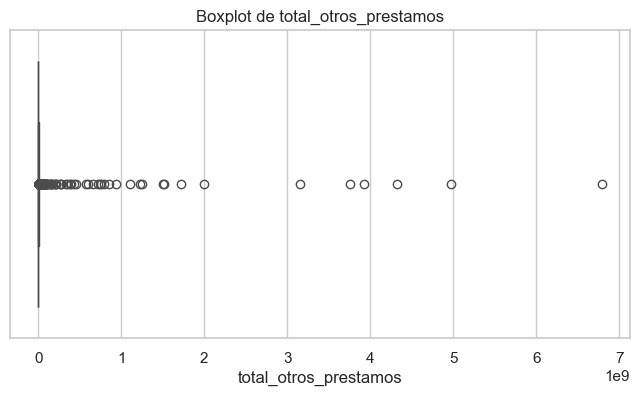

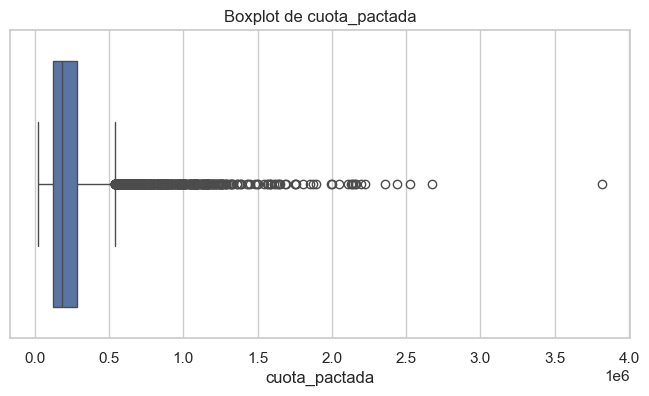

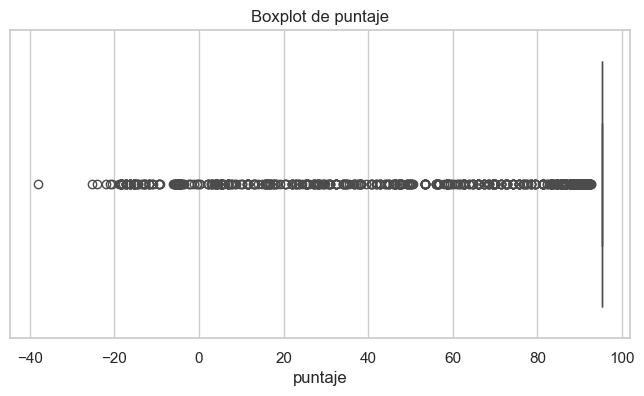

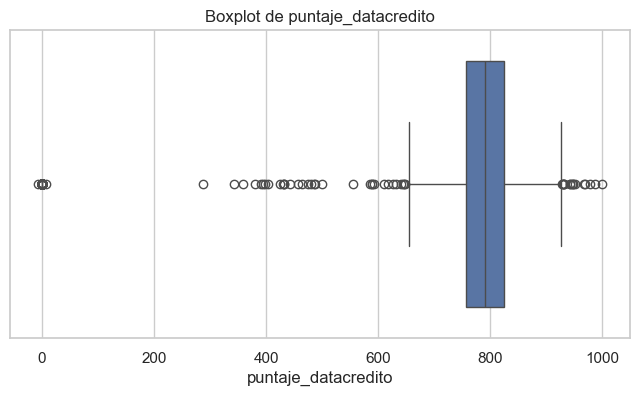

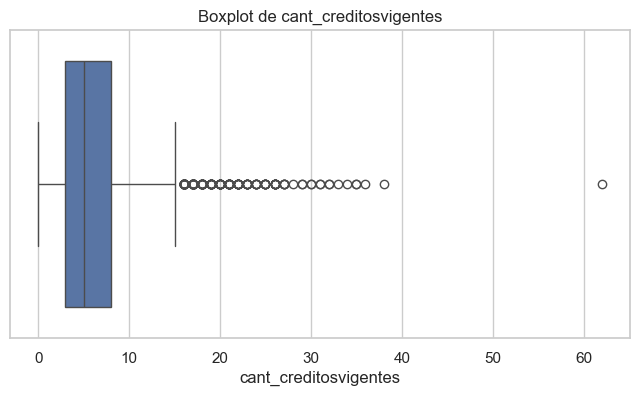

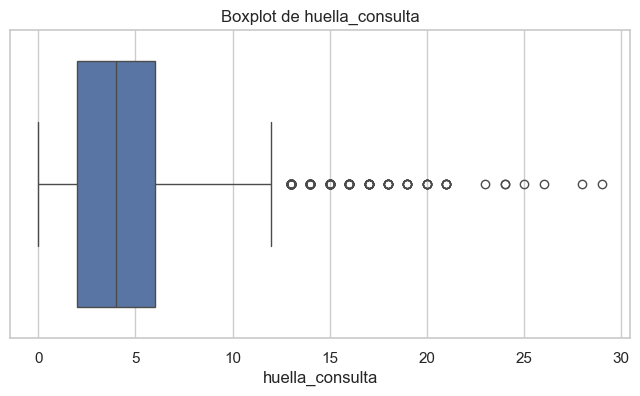

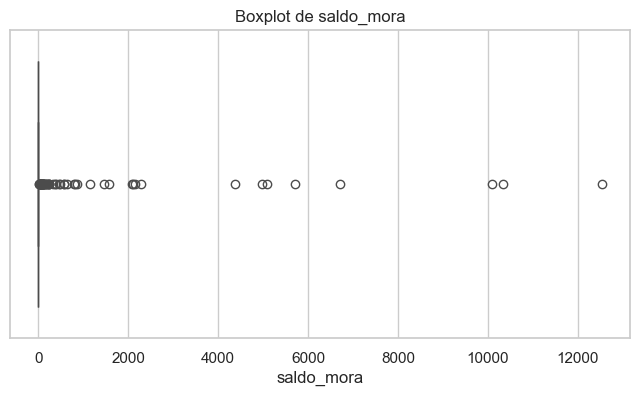

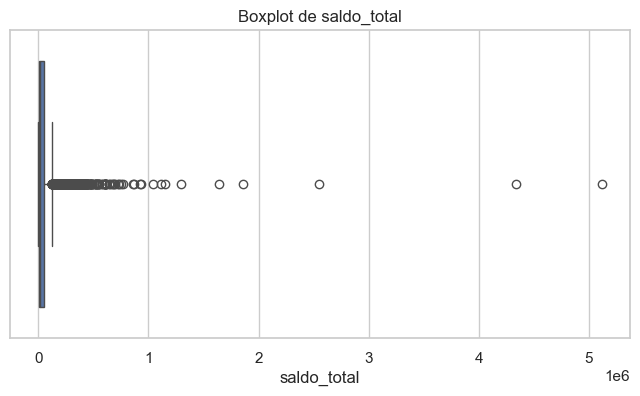

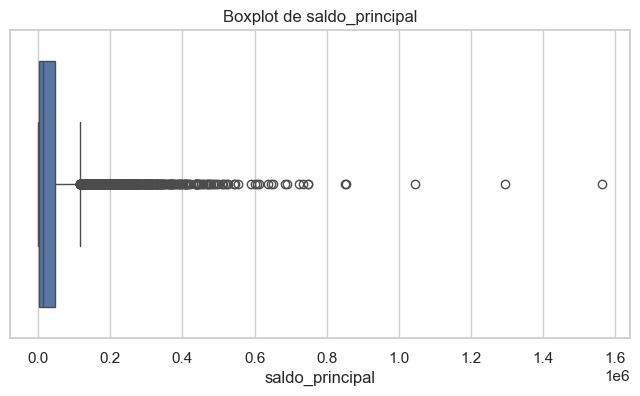

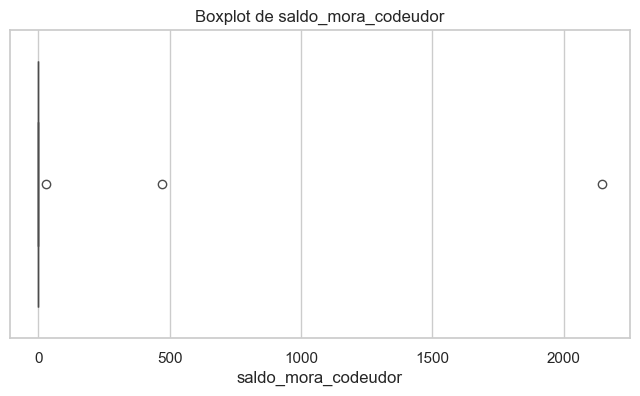

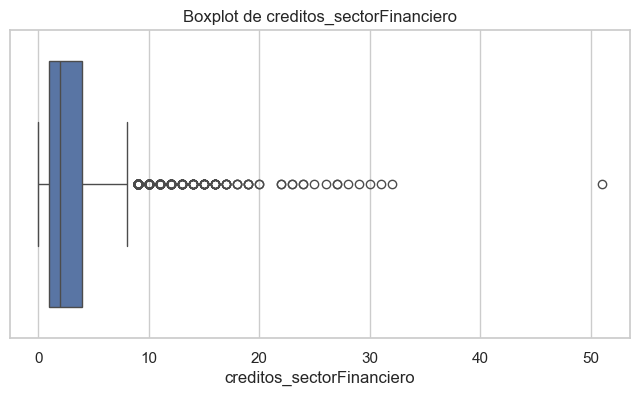

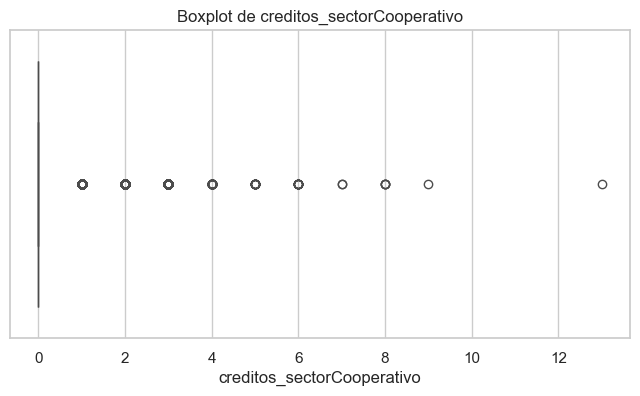

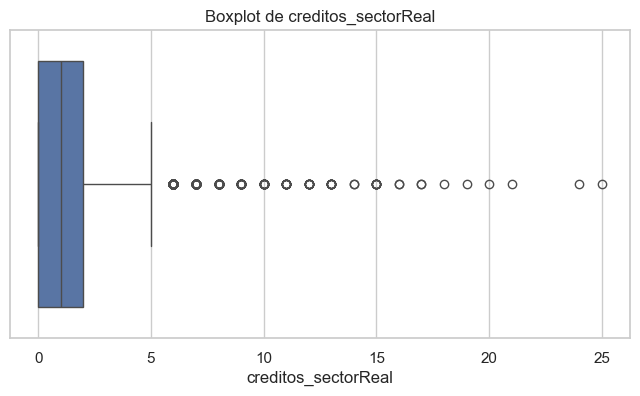

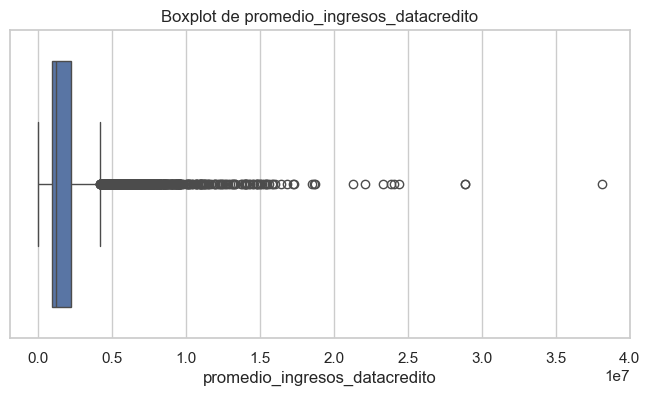

In [21]:
for col in variables_numericas_sin_target:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=col
    )

    plt.title(f"Boxplot de {col}")

    plt.show()

##  🔍 11. Variables categóricas

In [22]:
variables_categoricas = df.select_dtypes(
    include=["object", "category"]
).columns

variables_categoricas

Index(['tipo_credito', 'tipo_laboral', 'tendencia_ingresos'], dtype='object')

In [23]:
for col in variables_categoricas:

    print("=" * 60)
    print(f"Variable: {col}")
    print(df[col].value_counts(dropna=False))
    print()

Variable: tipo_credito
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

Variable: tipo_laboral
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

Variable: tendencia_ingresos
tendencia_ingresos
Creciente      5294
NaN            2932
Decreciente    1291
Estable        1188
0                 7
8315              6
1000000           4
9147              2
-101368           1
-70715            1
-702927           1
-224714           1
-164315           1
-566272           1
-435177           1
9090              1
5697              1
3978              1
-288              1
-28589            1
-4105             1
15090             1
10808             1
31837             1
52862             1
54683             1
15245             1
17181             1
22363             1
22832             1
24702             1
86286             1
82657             1
77975             1
75761             1
65988           

### Graficos

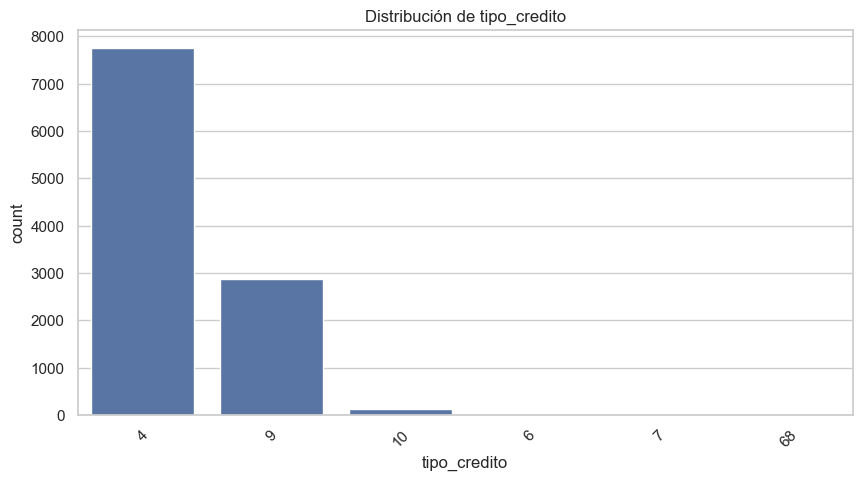

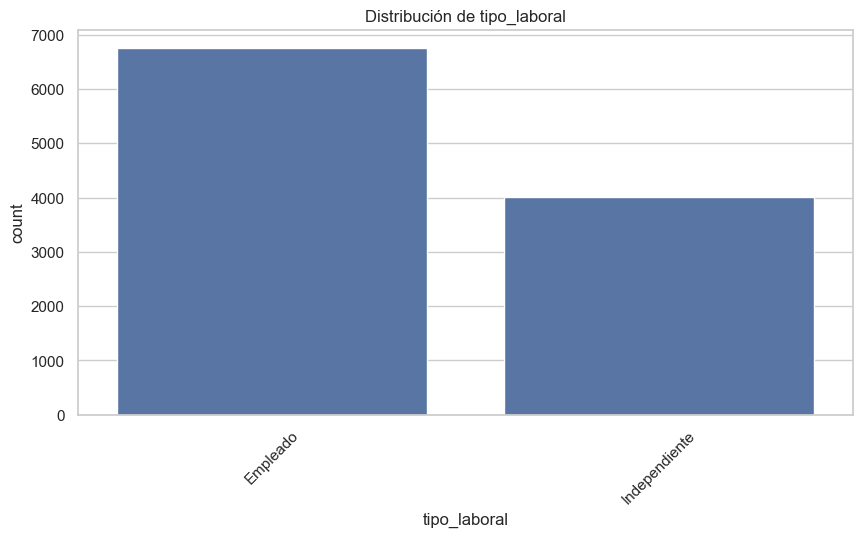

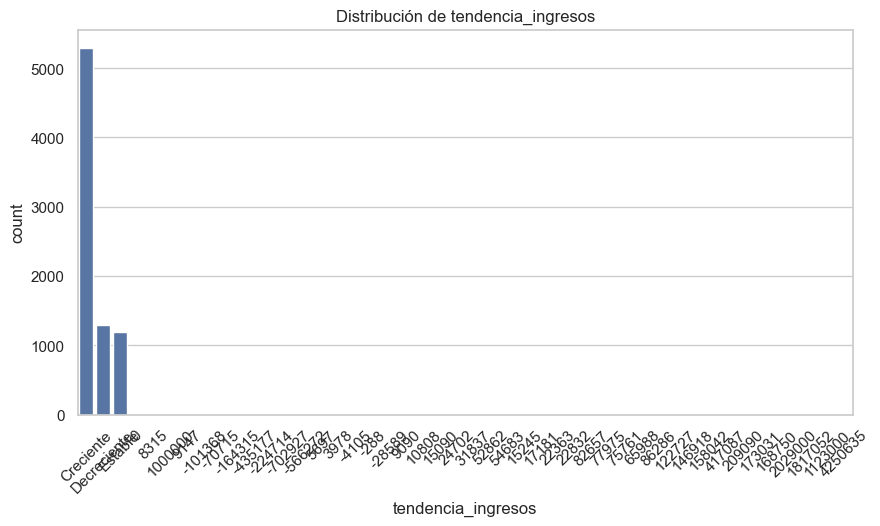

In [24]:
for col in variables_categoricas:

    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)

    plt.show()

##  🔬 12. Análisis bivariable
    Aquí vamos a analizar las variables respecto a Pago_atiempo

In [25]:
tabla_tipo_credito = pd.crosstab(
    df["tipo_credito"],
    df["Pago_atiempo"],
    normalize="index"
) * 100

tabla_tipo_credito

Pago_atiempo,0,1
tipo_credito,,
4,4.69,95.31
6,42.86,57.14
7,0.00,100.00
9,4.73,95.27
10,2.59,97.41
68,0.00,100.00


### Graficos

In [26]:
pd.crosstab(
    df["tipo_laboral"],
    df["Pago_atiempo"],
    normalize="index"
) * 100

Pago_atiempo,0,1
tipo_laboral,,
Empleado,4.29,95.71
Independiente,5.51,94.49


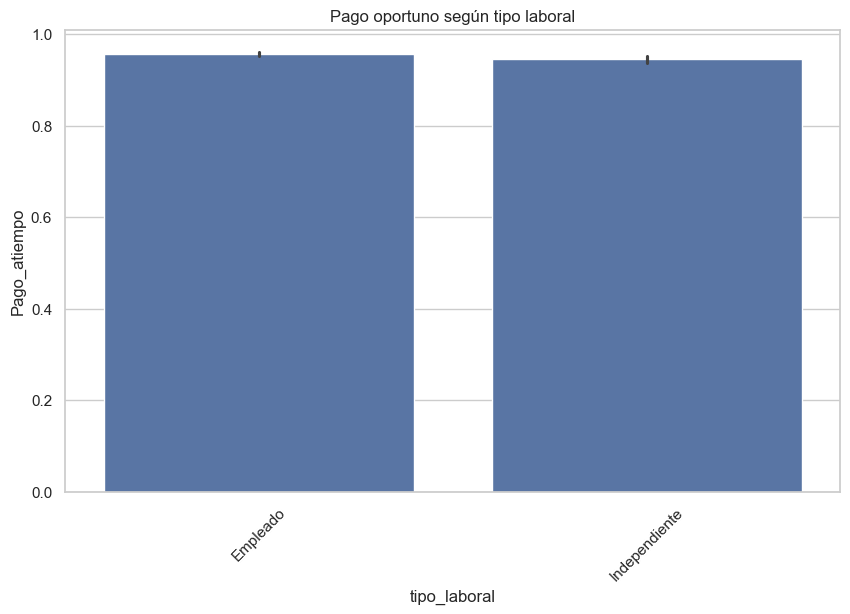

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="tipo_laboral",
    y="Pago_atiempo"
)

plt.title("Pago oportuno según tipo laboral")

plt.xticks(rotation=45)

plt.show()

## 📈  13. Variables numéricas vs objetivo
    Vamos a comparar las distribuciones de cada variable según el pago
    

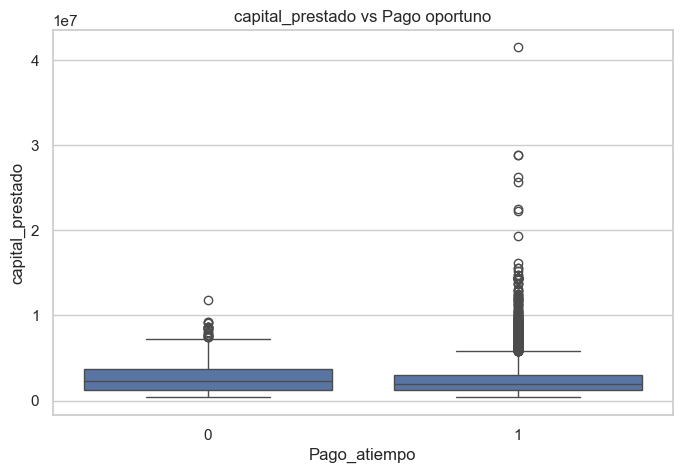

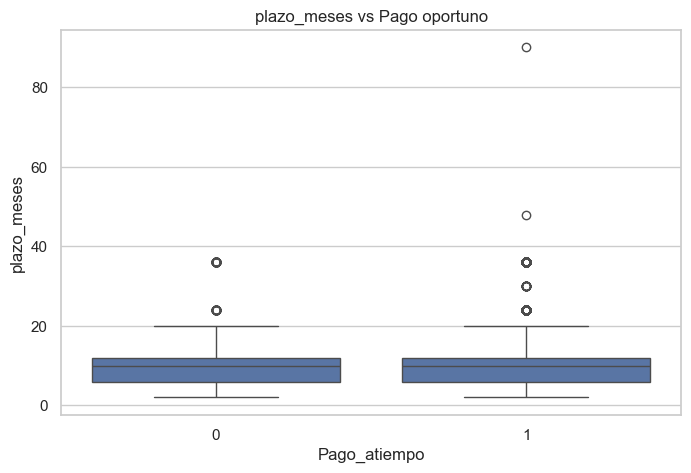

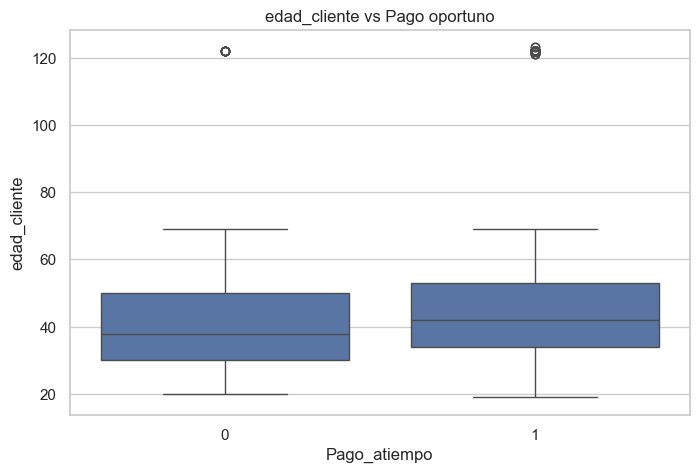

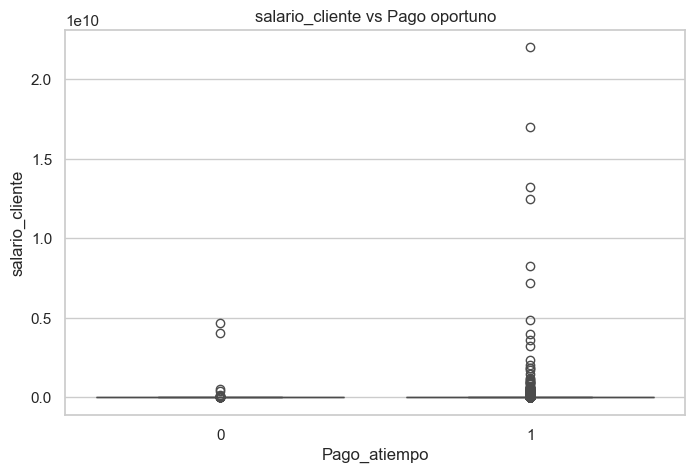

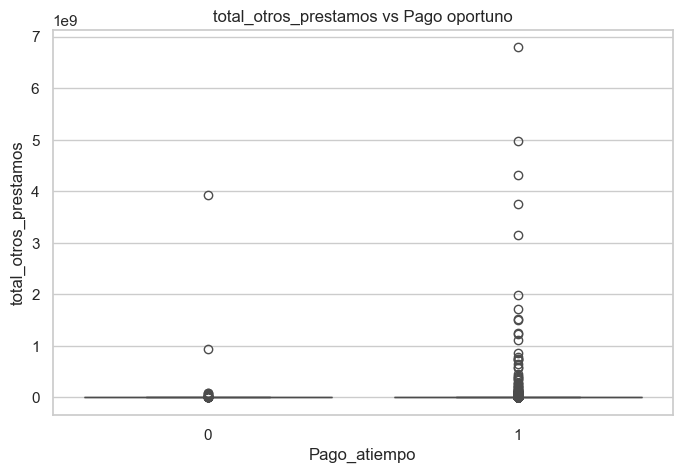

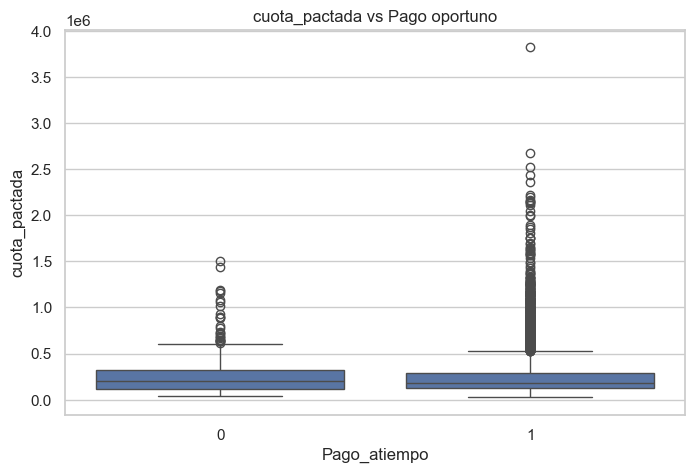

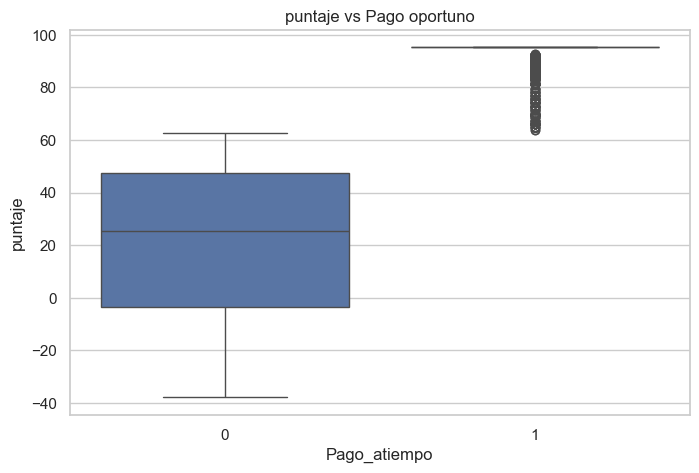

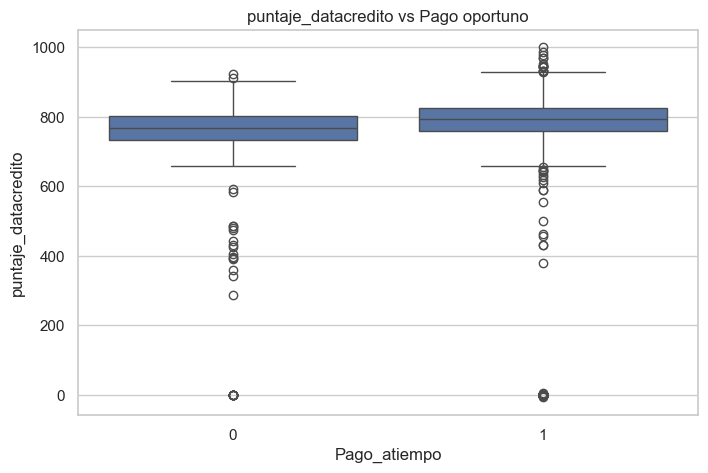

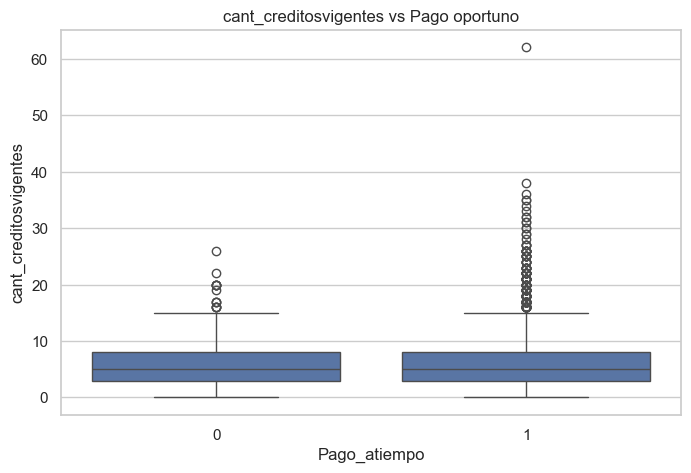

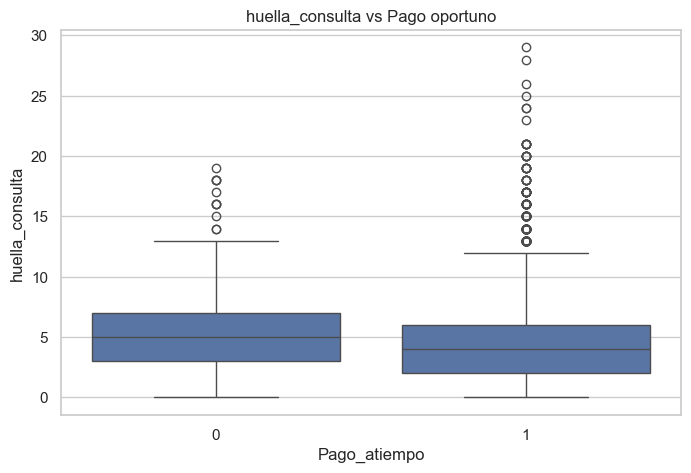

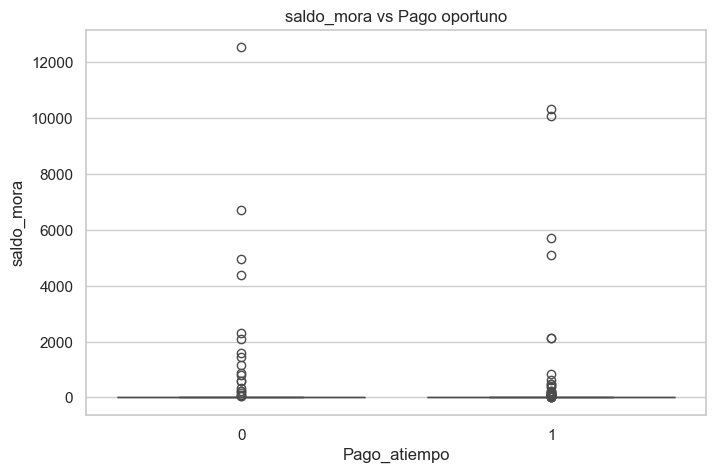

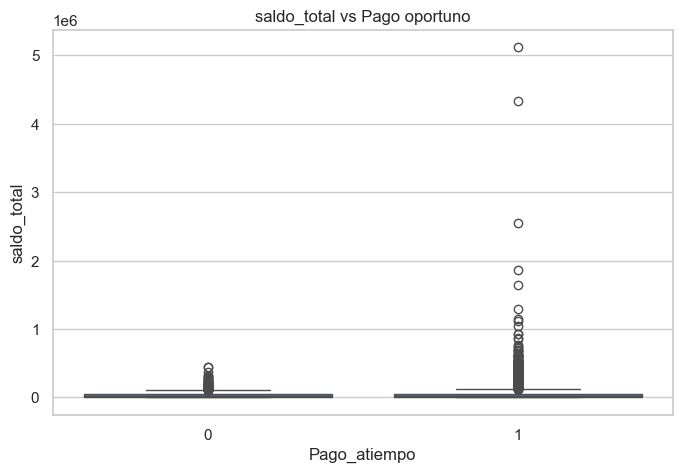

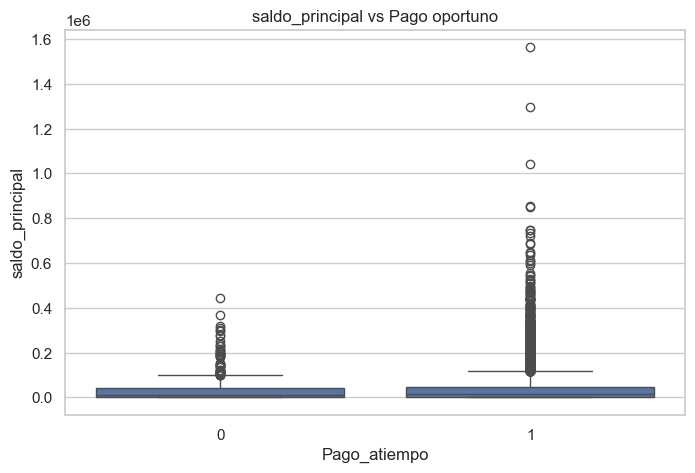

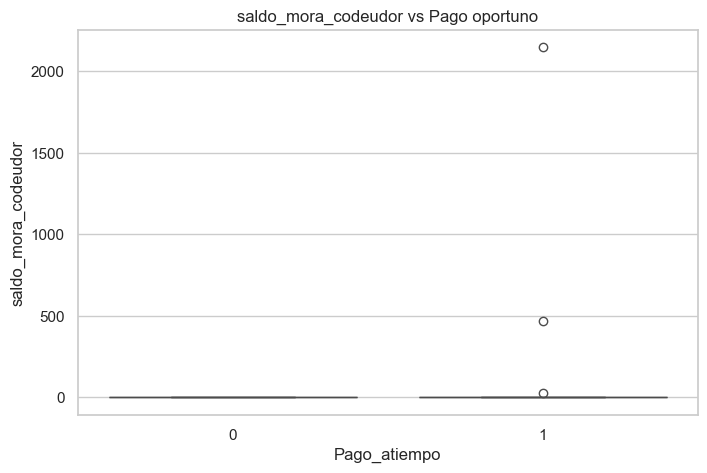

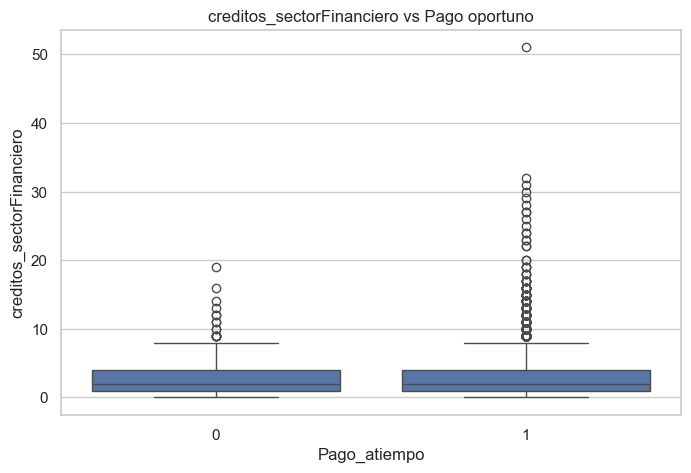

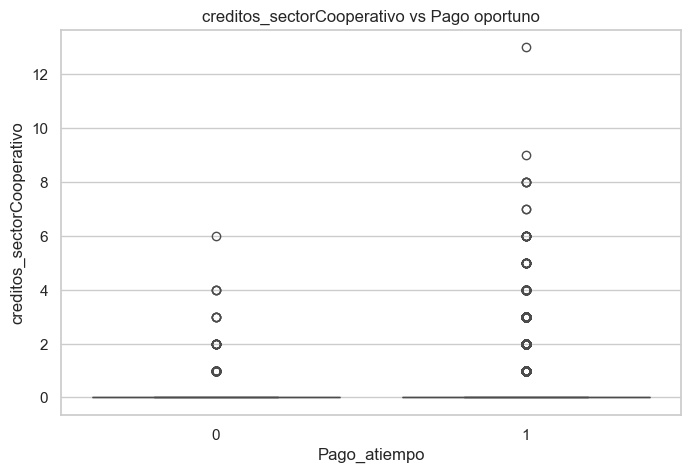

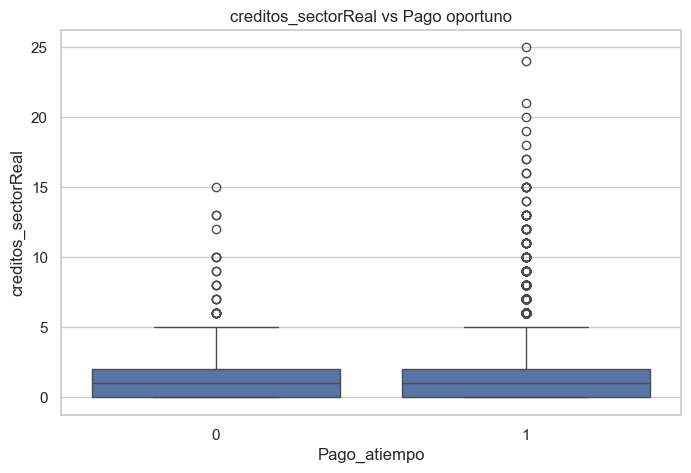

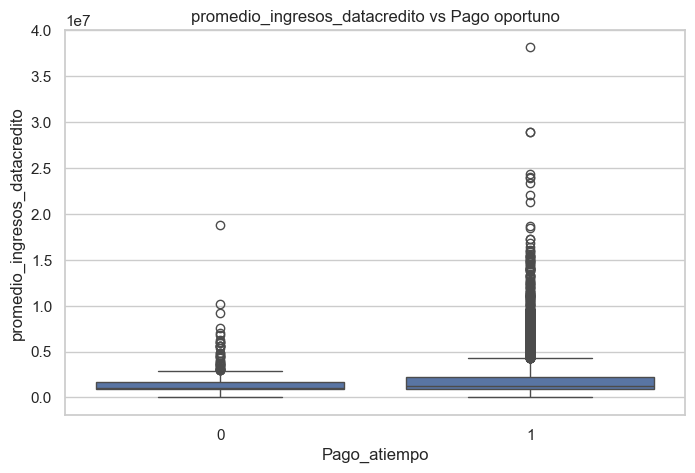

In [28]:
for col in variables_numericas_sin_target:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Pago_atiempo",
        y=col
    )

    plt.title(
        f"{col} vs Pago oportuno"
    )

    plt.show()

## 🔍 14. Análisis multivariable
    Matriz de correlación

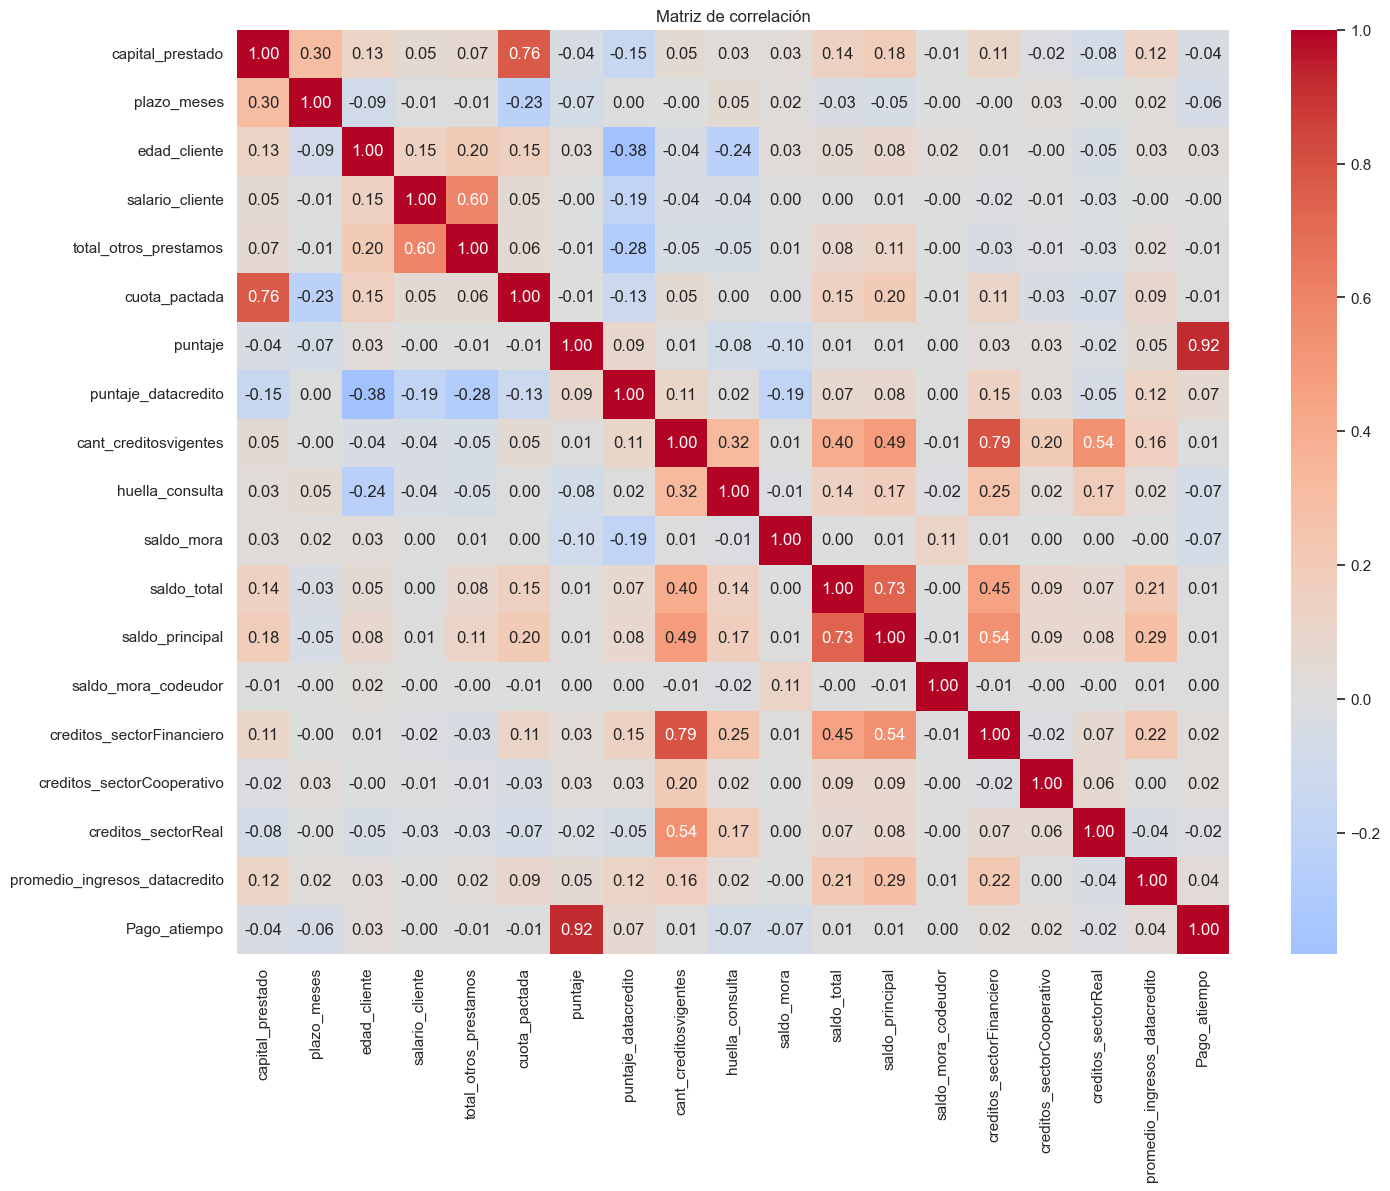

In [29]:
plt.figure(figsize=(16, 12))

correlacion = df[
    variables_numericas
].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()

## 📉  15. Pairplot
Para evitar gráficos excesivamente grandes, vamos a seleccionar las variables más relevantes

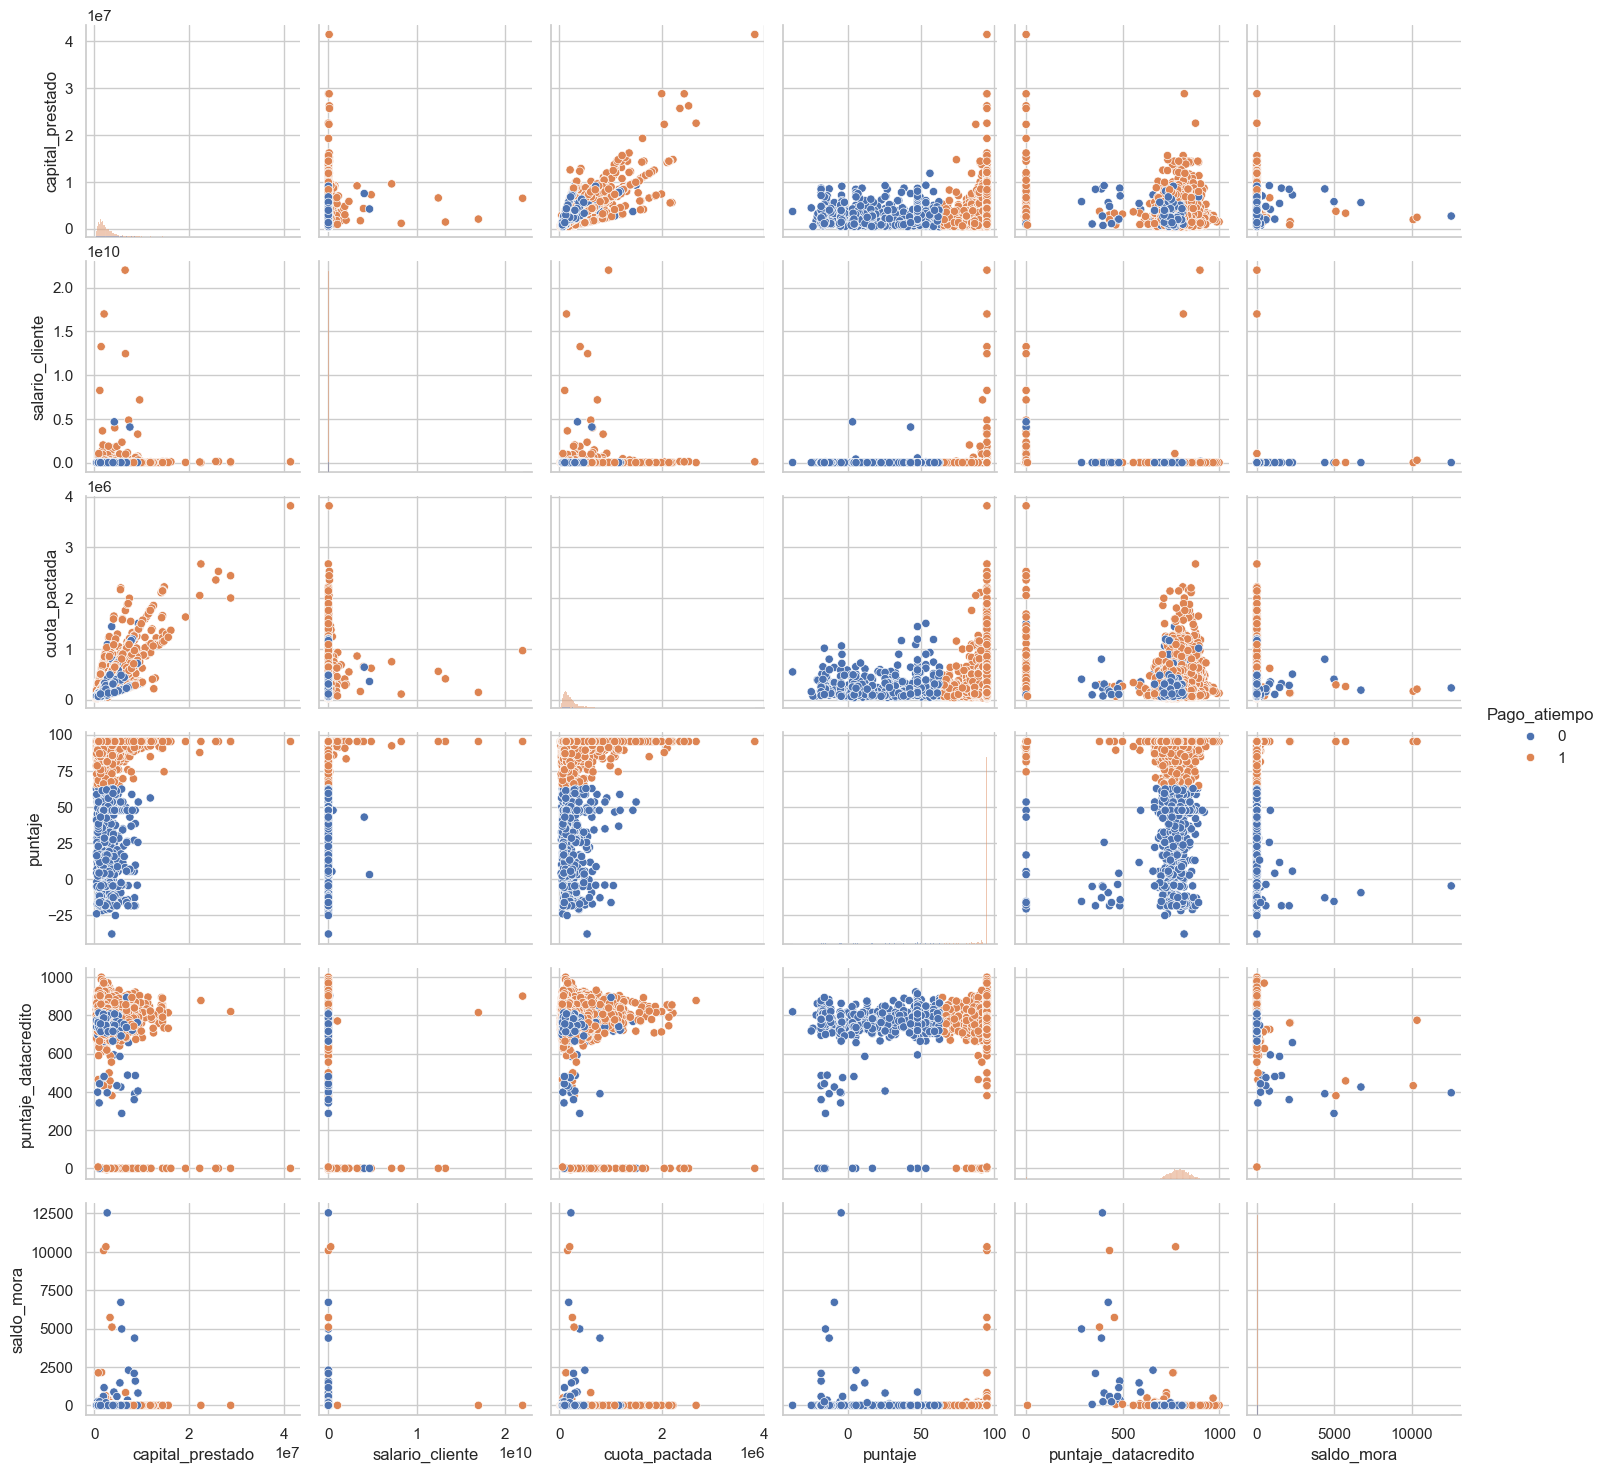

In [30]:
variables_pairplot = [
    "capital_prestado",
    "salario_cliente",
    "cuota_pactada",
    "puntaje",
    "puntaje_datacredito",
    "saldo_mora",
    "Pago_atiempo"
]

sns.pairplot(
    df[variables_pairplot],
    hue="Pago_atiempo",
    diag_kind="hist"
)

plt.show()

## 📋  16. Tablas cruzadas multivariables

In [31]:
tabla = pd.crosstab(
    [
        df["tipo_credito"],
        df["tipo_laboral"]
    ],
    df["Pago_atiempo"],
    normalize="index"
) * 100

tabla

Pago_atiempo                   0      1
tipo_credito tipo_laboral              
4            Empleado       4.14  95.86
             Independiente  5.71  94.29
6            Empleado      42.86  57.14
7            Empleado       0.00 100.00
             Independiente  0.00 100.00
9            Empleado       4.36  95.64
             Independiente  5.19  94.81
10           Empleado       2.67  97.33
             Independiente  2.44  97.56
68           Empleado       0.00 100.00

## 📊 17. Análisis temporal 

In [32]:
df["año"] = df["fecha_prestamo"].dt.year
df["mes"] = df["fecha_prestamo"].dt.month

In [33]:
df.groupby("año")["Pago_atiempo"].mean() * 100

año
2024   93.79
2025   95.51
2026   94.09
Name: Pago_atiempo, dtype: float64

In [34]:
df.groupby("mes")["Pago_atiempo"].mean() * 100

mes
1    95.45
2    94.10
3    94.89
4    93.71
5    95.66
6    96.24
7    96.89
8    96.40
9    98.06
10   98.27
11   94.32
12   94.46
Name: Pago_atiempo, dtype: float64

### Visualizacion

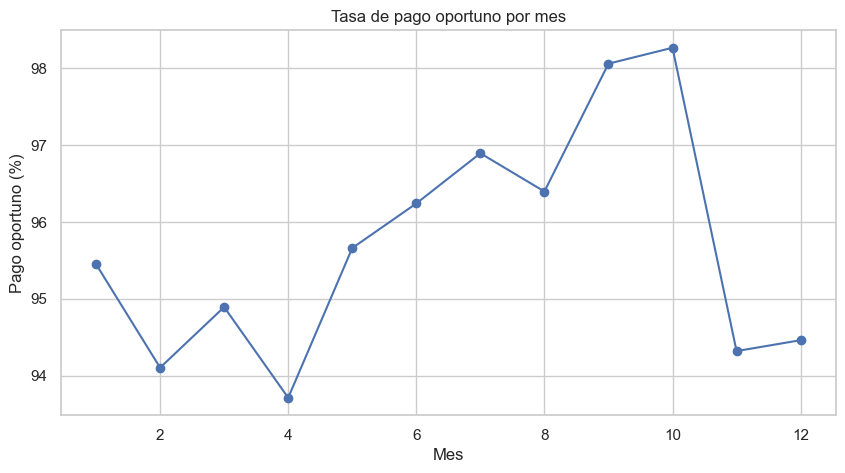

In [35]:
plt.figure(figsize=(10, 5))

(
    df.groupby("mes")["Pago_atiempo"]
    .mean()
    .mul(100)
    .plot(kind="line", marker="o")
)

plt.title("Tasa de pago oportuno por mes")
plt.ylabel("Pago oportuno (%)")
plt.xlabel("Mes")

plt.show()

## 18. Reglas de validación de datos

edad_cliente > 0,
edad_cliente <= 100,
salario_cliente >= 0,
capital_prestado > 0,
plazo_meses > 0

##### Puntajes

In [36]:
for col in [
    "puntaje",
    "puntaje_datacredito"
]:

    print(col)
    print(df[col].describe())

puntaje
count   10,763.00
mean        91.17
std         16.47
min        -38.01
25%         95.23
50%         95.23
75%         95.23
max         95.23
Name: puntaje, dtype: float64
puntaje_datacredito
count   10,757.00
mean       780.79
std        104.88
min         -7.00
25%        757.00
50%        791.00
75%        825.00
max        999.00
Name: puntaje_datacredito, dtype: float64


In [37]:
reglas_validacion = {
    "edad_cliente": "Debe estar entre 18 y 100 años",
    "salario_cliente": "Debe ser mayor o igual a 0",
    "capital_prestado": "Debe ser mayor a 0",
    "plazo_meses": "Debe ser mayor a 0",
    "cuota_pactada": "Debe ser mayor a 0",
    "saldo_mora": "Debe ser mayor o igual a 0",
    "Pago_atiempo": "Debe contener únicamente 0 o 1"
}

pd.DataFrame(
    reglas_validacion.items(),
    columns=["Variable", "Regla"]
)

,Variable,Regla
0,edad_cliente,Debe estar entre 18 y 100 años
1,salario_cliente,Debe ser mayor o igual a 0
2,capital_prestado,Debe ser mayor a 0
3,plazo_meses,Debe ser mayor a 0
4,cuota_pactada,Debe ser mayor a 0
5,saldo_mora,Debe ser mayor o igual a 0
6,Pago_atiempo,Debe contener únicamente 0 o 1


## 19. Variables derivadas

### Relacion cuota/ingreso

In [38]:
df["ratio_cuota_ingreso"] = (
    df["cuota_pactada"]
    / df["salario_cliente"]
)

### Nivel de endeudamiento total

In [39]:
df["deuda_total"] = (
    df["total_otros_prestamos"]
    + df["saldo_total"]
)

### Tiene Mora

In [40]:
df["tiene_mora"] = (
    df["saldo_mora"] > 0
).astype(int)

### Tiene codeudor con deuda

In [41]:
df["tiene_mora_codeudor"] = (
    df["saldo_mora_codeudor"] > 0
).astype(int)

In [45]:
df.head()

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,año,mes,ratio_cuota_ingreso,deuda_total,tiene_mora,tiene_mora_codeudor
0,7,2024-12-21 11:31:35,"3,692,160.00",10,42,Independiente,8000000,2500000,341296,88.77,695.00,10,5,0.00,"51,258.00","51,258.00",0.00,5,0,0,"908,526.00",Estable,1,2024,12,0.04,"2,551,258.00",0,0
1,4,2025-04-22 09:47:35,"840,000.00",6,60,Empleado,3000000,2000000,124876,95.23,789.00,3,1,0.00,"8,673.00","8,673.00",0.00,0,0,2,"939,017.00",Creciente,1,2025,4,0.04,"2,008,673.00",0,0
2,9,2026-01-08 12:22:40,"5,974,028.40",10,36,Independiente,4036000,829000,529554,47.61,740.00,4,5,0.00,"18,702.00","18,702.00",0.00,3,0,0,NaN,NaN,0,2026,1,0.13,"847,702.00",0,0
3,4,2025-08-04 12:04:10,"1,671,240.00",6,48,Empleado,1524547,498000,252420,95.23,837.00,4,4,0.00,"15,782.00","15,782.00",0.00,3,0,0,"1,536,193.00",Creciente,1,2025,8,0.17,"513,782.00",0,0
4,9,2025-04-26 11:24:26,"2,781,636.00",11,44,Empleado,5000000,4000000,217037,95.23,771.00,4,6,0.00,"204,804.00","204,804.00",0.00,3,0,1,"933,473.00",Creciente,1,2025,4,0.04,"4,204,804.00",0,0


# 20. 📊 Conclusiones del Análisis Exploratorio de Datos (EDA)

## 1. La base de datos presenta un volumen adecuado y una estructura multidimensional para el análisis predictivo

El conjunto de datos está compuesto por **10.763 registros y 23 variables**, que incluyen información relacionada con las características del crédito, perfil demográfico y laboral del cliente, ingresos, endeudamiento, comportamiento financiero e información proveniente de centrales de riesgo. La variable objetivo `Pago_atiempo` está correctamente identificada y presenta dos categorías, 0 y 1, lo que permite plantear el problema como una clasificación binaria. Esta estructura proporciona una base adecuada para desarrollar posteriormente un modelo predictivo orientado a estimar la probabilidad de pago oportuno.

## 2. La variable objetivo presenta un fuerte desbalance hacia el pago oportuno

La variable `Pago_atiempo` presenta una media de **0,9525**, lo que indica que aproximadamente el **95,25% de los registros corresponden a clientes que pagan a tiempo**, mientras que cerca del **4,75% representan casos de no pago oportuno**. Este resultado constituye uno de los hallazgos más relevantes del EDA, debido a que evidencia un **desbalance importante de clases**. Por lo tanto, en la etapa de modelamiento no será suficiente utilizar únicamente la exactitud (accuracy) como métrica de evaluación, ya que un modelo podría obtener una precisión aparentemente alta simplemente por predecir mayoritariamente la clase positiva. Será necesario considerar métricas como **precision, recall, F1-score, ROC-AUC y, especialmente, PR-AUC**, además de evaluar técnicas de balanceo cuando corresponda.

## 3. Los datos presentan una cantidad importante de valores faltantes concentrados en variables específicas

Aunque gran parte de las variables no presenta valores faltantes, existen variables que requieren un tratamiento especial. `promedio_ingresos_datacredito` tiene **2.930 valores faltantes, equivalentes al 27,22%**, y `tendencia_ingresos` presenta **2.932 valores faltantes, equivalentes al 27,24%**. Otras variables tienen niveles de ausencia menores, como `saldo_mora_codeudor` con 5,48%, `saldo_principal` con 3,76% y `saldo_mora` y `saldo_total` con 1,45%. Por lo tanto, la decisión de eliminar directamente estas variables del modelo debe ser revisada, ya que la ausencia de información podría contener información relevante sobre el perfil del cliente. Se recomienda evaluar una estrategia de imputación acompañada de una variable indicadora de ausencia (`missing indicator`), especialmente para las variables con aproximadamente 27% de datos faltantes.

## 4. Las variables financieras presentan distribuciones altamente asimétricas y presencia de valores extremos

Las variables relacionadas con el salario, otros préstamos, capital prestado, cuotas y saldos presentan una fuerte asimetría positiva. Por ejemplo, `salario_cliente` tiene una media de aproximadamente **17,2 millones**, pero una mediana de solo **3 millones**, con un máximo de **22.000 millones** y un skewness de **43,78**. De manera similar, `total_otros_prestamos` presenta una media de aproximadamente **6,24 millones**, una mediana de **1 millón** y un máximo superior a **6.787 millones**. Estos resultados evidencian la presencia de valores extremos que pueden distorsionar los análisis estadísticos y afectar algunos algoritmos de machine learning. Se recomienda investigar estos registros, determinar si corresponden a valores reales o errores de captura y, dependiendo del modelo seleccionado, evaluar transformaciones logarítmicas, winsorización o métodos robustos.

## 5. Se identifican inconsistencias que requieren reglas de validación antes del modelamiento

El análisis estadístico revela valores que deben ser revisados desde el punto de vista de calidad de datos. La variable `edad_cliente` alcanza un máximo de **123 años**, mientras que `puntaje` presenta valores mínimos negativos de aproximadamente **-38** y `puntaje_datacredito` valores mínimos de **-7**. Adicionalmente, `salario_cliente` contiene valores iguales a cero y presenta máximos extremadamente elevados. Estos resultados sugieren que no todos los valores extremos deben tratarse automáticamente como outliers estadísticos: algunos podrían representar errores de captura o inconsistencias de negocio. Por ello, antes del modelamiento se deben definir reglas de validación, por ejemplo, rangos razonables de edad, puntajes válidos y valores financieros no negativos.

## 6. La variable `tendencia_ingresos` presenta un problema de calidad que debe corregirse

El análisis de variables categóricas revela una situación especialmente importante en `tendencia_ingresos`. Aunque las categorías esperadas son `Creciente`, `Decreciente` y `Estable`, la variable también contiene valores numéricos, valores negativos y otros registros atípicos. Se identifican **5.294 registros como "Creciente"**, **1.291 como "Decreciente"**, **1.188 como "Estable"** y **2.932 valores nulos**, pero además aparecen múltiples valores numéricos que no corresponden a categorías válidas. Esto indica una posible contaminación o transformación incorrecta de la variable. Antes de utilizarla en un modelo, se debe investigar su origen, identificar qué representan esos valores numéricos y establecer una regla de limpieza o recodificación. Este hallazgo también demuestra que la validación de tipos de datos no debe limitarse a revisar si una variable es `object` o `numeric`, sino que debe comprobar la coherencia semántica de sus valores.

## 7. La variable `puntaje` presenta una distribución poco confiable que debe investigarse antes de utilizarla como predictor

El análisis descriptivo de `puntaje` muestra una mediana de **95,23**, un máximo también de **95,23**, pero un mínimo de **-38,01**, con una asimetría de **-4,87**. El hecho de que el tercer cuartil, la mediana y el máximo coincidan en 95,23, mientras existen valores negativos, sugiere que la variable podría estar limitada por un valor superior o contener una codificación especial para ciertos registros. Antes de incorporarla directamente a un modelo, es recomendable analizar su distribución detalladamente, identificar la proporción de valores negativos y determinar si estos representan valores faltantes codificados, ausencia de información o errores. Este análisis es fundamental porque una variable de score mal interpretada podría introducir ruido o sesgo en el modelo.

## 8. Las variables relacionadas con endeudamiento y comportamiento financiero tienen potencial para construir indicadores derivados de mayor valor analítico

La base contiene información sobre `total_otros_prestamos`, `cuota_pactada`, `cant_creditosvigentes`, `saldo_mora`, `saldo_total`, `saldo_principal` y créditos distribuidos por diferentes sectores. El análisis muestra una elevada dispersión y asimetría en varias de estas variables, por lo que resulta conveniente complementar los valores absolutos con indicadores relativos. Se recomienda crear variables como **ratio cuota-ingreso**, **ratio deuda-ingreso**, **ratio capital-ingreso**, **deuda total**, **número total de créditos**, **indicador de presencia de mora** y **proporción del saldo en mora sobre el saldo total**. Estas variables podrían representar mejor la capacidad de pago y el nivel de exposición financiera del cliente y deben ser evaluadas posteriormente como posibles predictores de `Pago_atiempo`.

## 9. La información laboral y crediticia permite segmentar diferentes perfiles de clientes

La población analizada está compuesta por **6.754 empleados y 4.009 independientes**, lo que representa aproximadamente un 63% y 37% respectivamente. Asimismo, existen seis códigos principales de `tipo_credito`, aunque la distribución está fuertemente concentrada en los tipos 4 y 9, que reúnen la gran mayoría de los registros. Esta concentración debe considerarse al realizar análisis bivariable y multivariable, ya que las categorías con pocos registros pueden producir resultados inestables. Se recomienda analizar `Pago_atiempo` por tipo de crédito y situación laboral, así como estudiar posibles interacciones entre estas variables y las características financieras del cliente.

## 10. El principal reto de la siguiente etapa será construir un proceso robusto de calidad, transformación y modelamiento que considere el fuerte desbalance de la variable objetivo

En conjunto, el EDA demuestra que el dataset contiene información valiosa para predecir el comportamiento de pago, pero requiere una etapa adicional de preparación antes de entrenar modelos. Las principales acciones recomendadas son: corregir las inconsistencias de `tendencia_ingresos`, validar los valores extremos y potencialmente inválidos de edad, puntajes e ingresos, analizar el tratamiento de los valores faltantes, revisar la distribución y codificación de `puntaje`, crear variables financieras derivadas y establecer un protocolo de validación de datos. Además, debido a que aproximadamente el **95,25% de los registros corresponden a pagos oportunos**, la evaluación del modelo deberá centrarse en su capacidad para identificar correctamente la clase minoritaria y no únicamente en la exactitud global. El resultado del EDA permite, por tanto, definir una hoja de ruta clara para las siguientes fases: **limpieza y validación → imputación y tratamiento de valores faltantes → feature engineering → selección de variables → balanceo de clases → modelamiento → evaluación y monitoreo**.
